# Lab 3 - Tree-based Learning: Classifiying Particle Physics Data

In this lab, you will learn to:
* Build a decision tree manually
* Build a classifer using random forest with sklearn
* Visualize decision trees
* Build regression model using random forest
* Learn about additional performance metrics and hyper-parameter tuning. 
* Build a classifier for particle physics data

Authors: Tuan Do & Bernie Boscoe

Latest Revision: Tuan Do

In [1]:
# put your imports here
import numpy as np
import pandas as pd
import pylab as plt

# Part A - Building a decision tree by hand

From Question 2 from Chapter 4 of Kelleher 


A convicted criminal who reoffends after release is known as a recidivist. The table below lists a dataset that describes prisoners released on parole, and whether they reoffended within two years of release. This dataset lists six instances where prisoners were granted parole. Each of these instances are described in terms of three binary descriptive features. (GOOD BEHAVIOR, AGE ă 30, DRUG DEPENDENT) and a binary target feature, RECIDIVIST. The GOOD BEHAVIOR feature has a value of true if the prisoner had not committed any infringements during incarceration, the AGE ă 30 has a value of true if the prisoner was under 30 years of age when granted parole, and the DRUG DEPENDENT feature is true if the prisoner had a drug addiction at the time of parole. The target feature, RECIDIVIST, has a true value if the prisoner was arrested within two years of being released; otherwise it has a value of false.


<img src="table.png" alt="drawing" width="600"/>

Note: This example of predicting recidivism is based on a real application of machine learning: parole boards do rely on machine learning prediction models to help them when they are making their decisions. See Berk and Bleich (2013) for a recent comparison of different machine learning models used for this task. Datasets dealing with prisoner recidivism are available online, for exam- ple: catalog.data.gov/dataset/prisoner-recidivism/. The dataset presented here is not based on real data.


### Part A1

### Question 1
(5 pts)

Using this dataset, construct the decision tree that would be generated by the ID3 algorithm, using entropy-based information gain. Show your calculations for information gain and draw your final tree. Hint: follow the example in 4.3.1 in Kelleher. Note, you can upload a separate PDF for this question if you would like to draw or calculate on paper. 

### Part A2

### Question 2
(1 pt)

What prediction will the decision tree generated in part 1.1 return for the following query?
GOOD BEHAVIOR = false,AGE < 30 = false, DRUG DEPENDENT = true

# Answer: 
True

### Part A3

### Question 3

(1 pt)

What prediction will the decision tree generated in part 1.1 predict for the following query?

GOOD BEHAVIOR = true,AGE < 30 = true, DRUG DEPENDENT = false

# Answer: 
True

### Part A4 

### Question 4
(1 pt)

Discuss why this decision tree might lead to biases in inferences about recividism.

# Answer:
The decision is made in lower depth without utilising all features.

# Part B - Classify irises with a decision tree

Here, we'll repeat the iris classification problem with a decision tree using continuous features. We'll also be using the sklearn decision tree classifier.  


In [2]:
# load the data and the module to visualize decision trees
from sklearn.datasets import load_iris
from sklearn import tree

import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
from sklearn.metrics import accuracy_score
from sklearn import datasets, model_selection
import pandas as pd
import seaborn as sns


## B1 Building a decision tree with 2 features



## Question 5

(1 pt)

Load the iris data set. Let's start by using only **2 features: sepal length and width**


In [171]:
# enter code here, hint: use your code from  your previous labs to load the iris dataset
iris = load_iris()
data1 = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])
data = np.array(data1.iloc[:,0:2])
targets = np.array(data1.target)

**Split the data into training and testing data**

In [172]:
np.random.seed(10)
# Run this code to randomly shuffle the data and make train and validation splits
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data, targets, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

# enter code here

## Question 6
(2 pts)

**Load the classifier**

See the sklearn documentation for more info: https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html

In [173]:
# load the classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(random_state=0,criterion='entropy')

**Train the classifier**

In [40]:
# enter your code here

In [174]:
clf.fit(x_train,y_train)

,criterion,'entropy'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**Visualize your decision tree.** Sklearn has a nice function called tree.plot_tree that will plot the tree you created. 

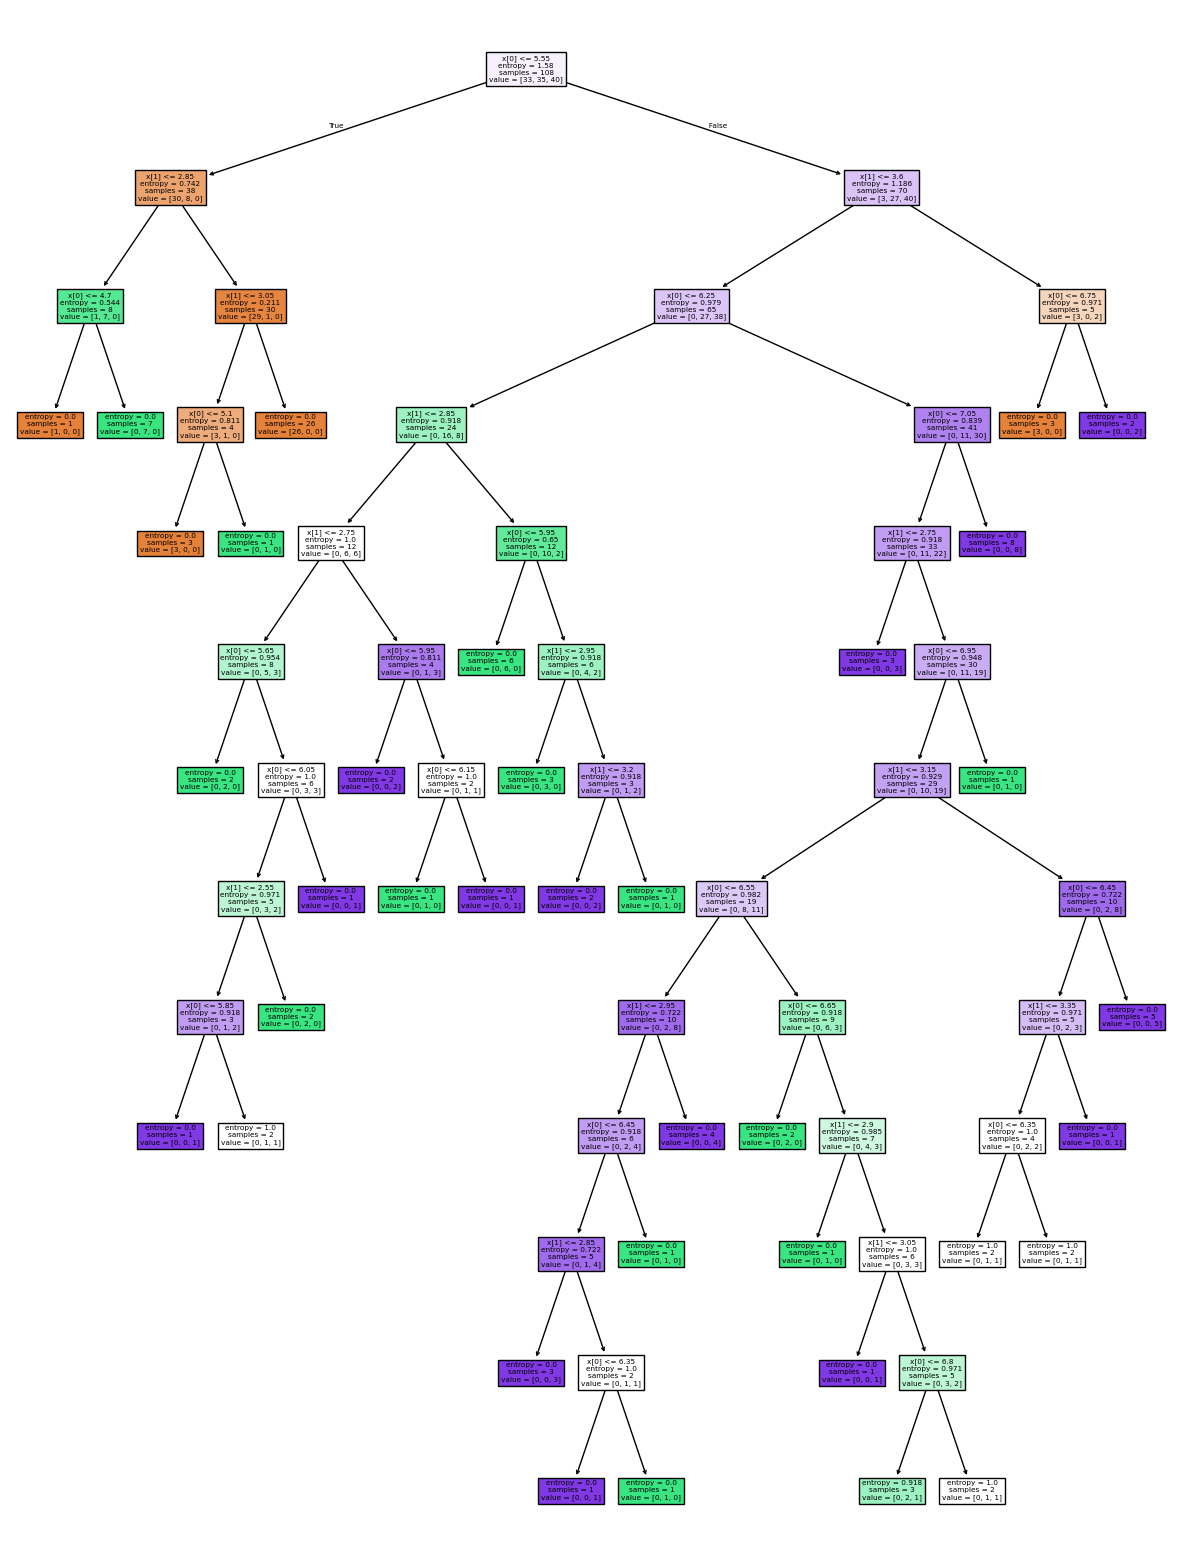

In [7]:
# visualize the tree that was created
plt.figure(figsize=(15,20))
t = tree.plot_tree(clf,filled=True)

## Question 7
(2 pts)

Describe the tree that you created. **Where which feature did the root node use to split? Why? How deep is it? Why is it that deep?**

# A:
Root node uses x[0] which is sepal length, asking if sepal length is less than 5.55 cm or not. We used the entropy for the measure of splitting power.  The depth is 12 (if it counts from 0, 11). It is because either there is no more classification possible or further splitting is not entropically favored.

Test the classifier using the **accuracy score**.

# A:
70% accuracy

In [175]:
# enter your code here
clf.fit(x_train, y_train)
clf.score(x_test, y_test)

0.7037037037037037

**Visualization:** we can visualize how different pairs of iris features would give in terms of their classification in the iris problem. **Run the code cell below to see this decision surface for different pairs of features.** 

/tmp/ipykernel_77/1378001726.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_77/1378001726.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_77/1378001726.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_77/1378001726.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/ipykernel_77/1378001726.py:38: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
/tmp/

(np.float64(0.0),
 np.float64(7.88),
 np.float64(-0.9),
 np.float64(3.4800000000000044))

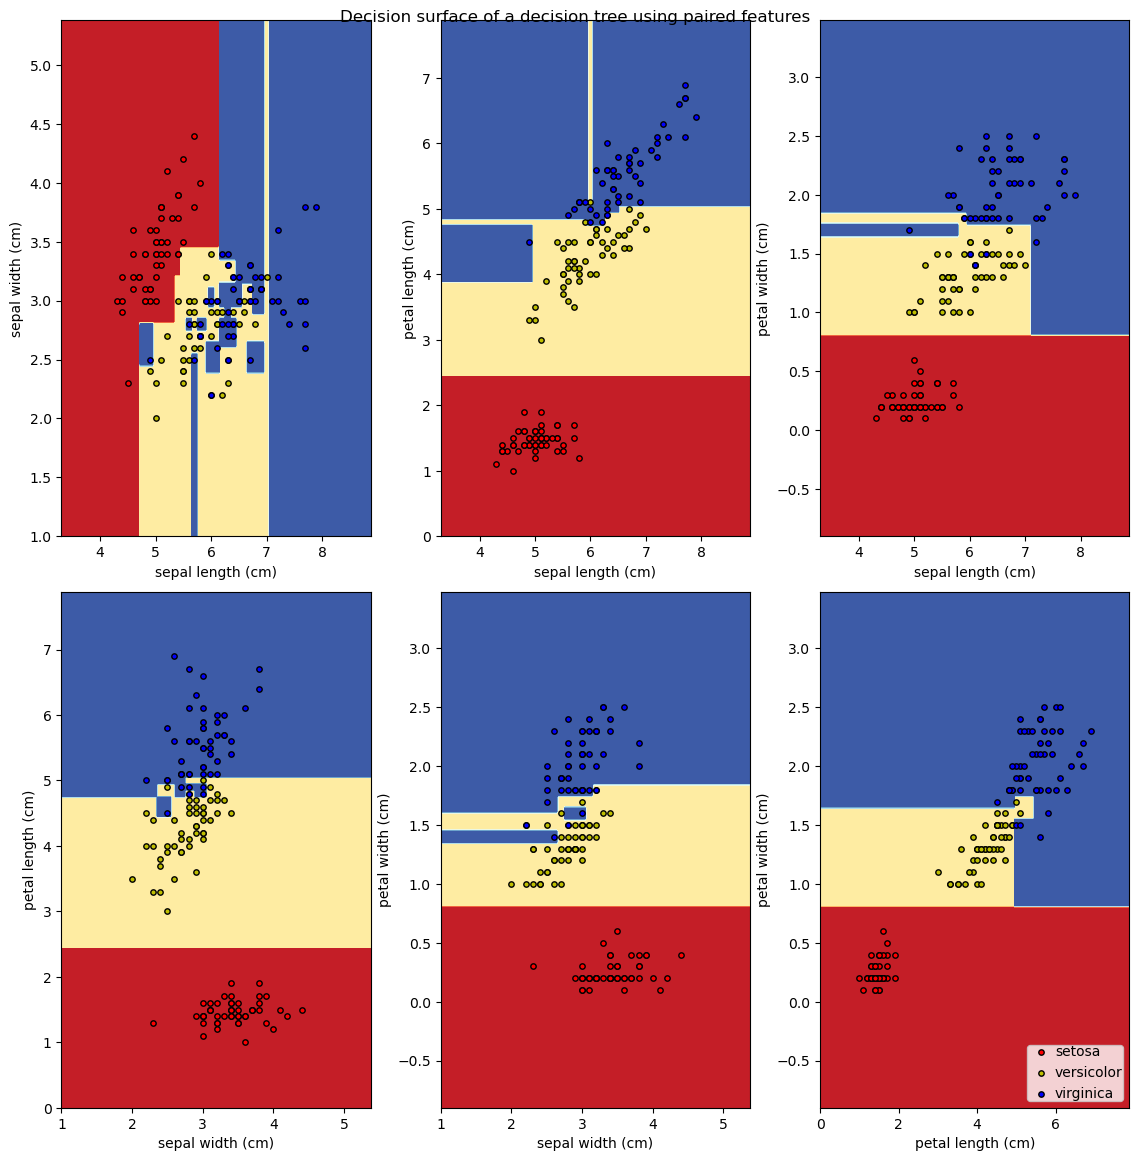

In [8]:

# Parameters
n_classes = 3
plot_colors = "ryb"
plot_step = 0.02

# Load data
iris = load_iris()
plt.figure(figsize=(12,12))

for pairidx, pair in enumerate([[0, 1], [0, 2], [0, 3],
                                [1, 2], [1, 3], [2, 3]]):
    # We only take the two corresponding features
    X = iris.data[:, pair]
    y = iris.target

    # Train
    clf = tree.DecisionTreeClassifier().fit(X, y)

    # Plot the decision boundary
    plt.subplot(2, 3, pairidx + 1)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                         np.arange(y_min, y_max, plot_step))
    plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu)

    plt.xlabel(iris.feature_names[pair[0]])
    plt.ylabel(iris.feature_names[pair[1]])

    # Plot the training points
    for i, color in zip(range(n_classes), plot_colors):
        idx = np.where(y == i)
        plt.scatter(X[idx, 0], X[idx, 1], c=color, label=iris.target_names[i],
                    cmap=plt.cm.RdYlBu, edgecolor='black', s=15)

plt.suptitle("Decision surface of a decision tree using paired features")
plt.legend(loc='lower right', borderpad=0, handletextpad=0)
plt.axis("tight")

## Question 8
(1 pt)

Based on the plot above, **identify some regions where overfitting is occurring.**

# A:
There are some islands that correctly classifying the outliers in the training sample.  This is overfitting, which is sensitive to the small fluctuation (outliers here).

## Question 9
(2 pt)

By default, the decision tree can be too deep, which can make it overfit. **Recreate the classifier and use the keyword ``max_depth`` in the ``DecisionTreeClassifier`` object to specify a depth for your tree. Try refitting the data. Does your accuracy score improve?**

# A:
The accuracy score improved from 70% to 81%.

In [9]:
# your code here
clf = DecisionTreeClassifier(random_state=0,criterion='entropy',max_depth=6)
clf.fit(x_train, y_train)
clf.score(x_test, y_test)

0.8148148148148148

## B2 Building a decision tree with all features

## Question 10
(4 pts)

Now that you have a sense of how the decision tree works with sklearn, **build a decision tree to classify 
irises using all the features and test it.** 

0.8888888888888888


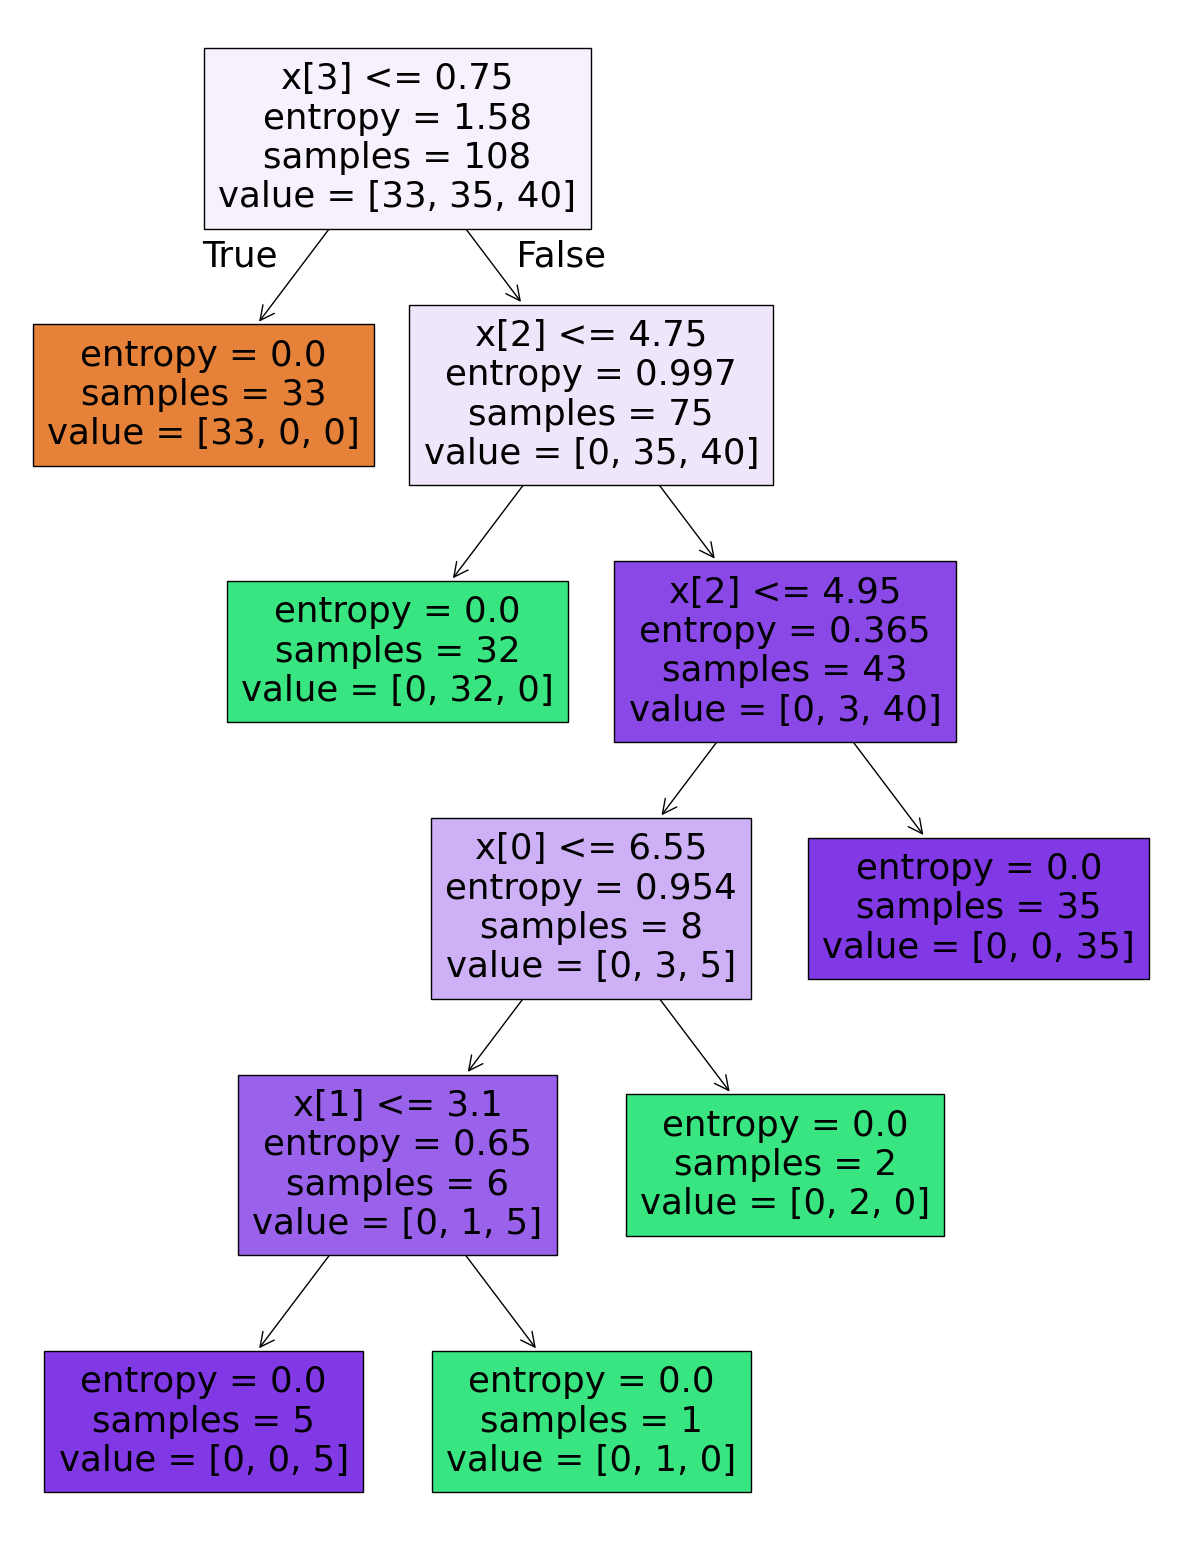

In [177]:
# your code here
iris = load_iris()
data1 = pd.DataFrame(data= np.c_[iris['data'], iris['target']],
                     columns= iris['feature_names'] + ['target'])

data2 = np.array(data1.iloc[:,0:4])
targets = np.array(data1.target)

np.random.seed(10)
x_train_all_2, x_validate_2, y_train_all_2, y_validate_2 = model_selection.train_test_split(data2, targets, test_size=0.1)

# now split the training data further into training and testing
x_train_2, x_test_2, y_train_2, y_test_2 = model_selection.train_test_split(x_train_all_2, y_train_all_2, test_size=0.2)

clf2 = DecisionTreeClassifier(random_state=0,criterion='entropy')
clf2.fit(x_train_2, y_train_2)
print(clf2.score(x_test_2, y_test_2))

plt.figure(figsize=(15,20))
t = tree.plot_tree(clf2,filled=True)
# enter code here

## Question 11
(4 pts)

Based on your new tree, answer the following questions:
    
- **What feature does this tree split on? Why?**
- **What is your new accuracy score?**
- **Examine whether your score improves by changing ``max_depth``.** 
- By default, the classifer uses the Gini index to split the nodes. **What happens if you use information entropy instead?**

# your answers here
(1) It uses sepal width (x[3]) at the root which already predicts if the value is true and in the further down, uses every feature.

(2) The accuracy score is 0.89 (rounded) for depth 5 (6 levels).

(3) The accuracy doesn't change until I lower the max_depth to 1, which is lowered.

(4) In the following cells: We used entropy above; changing to gini doesn't change the accuracy score.

In [178]:
# 3 code:
clf3 = DecisionTreeClassifier(random_state=0,criterion='entropy',max_depth=1)
clf3.fit(x_train_2, y_train_2)

print(clf3.score(x_test_2, y_test_2))

0.7407407407407407


0.8888888888888888


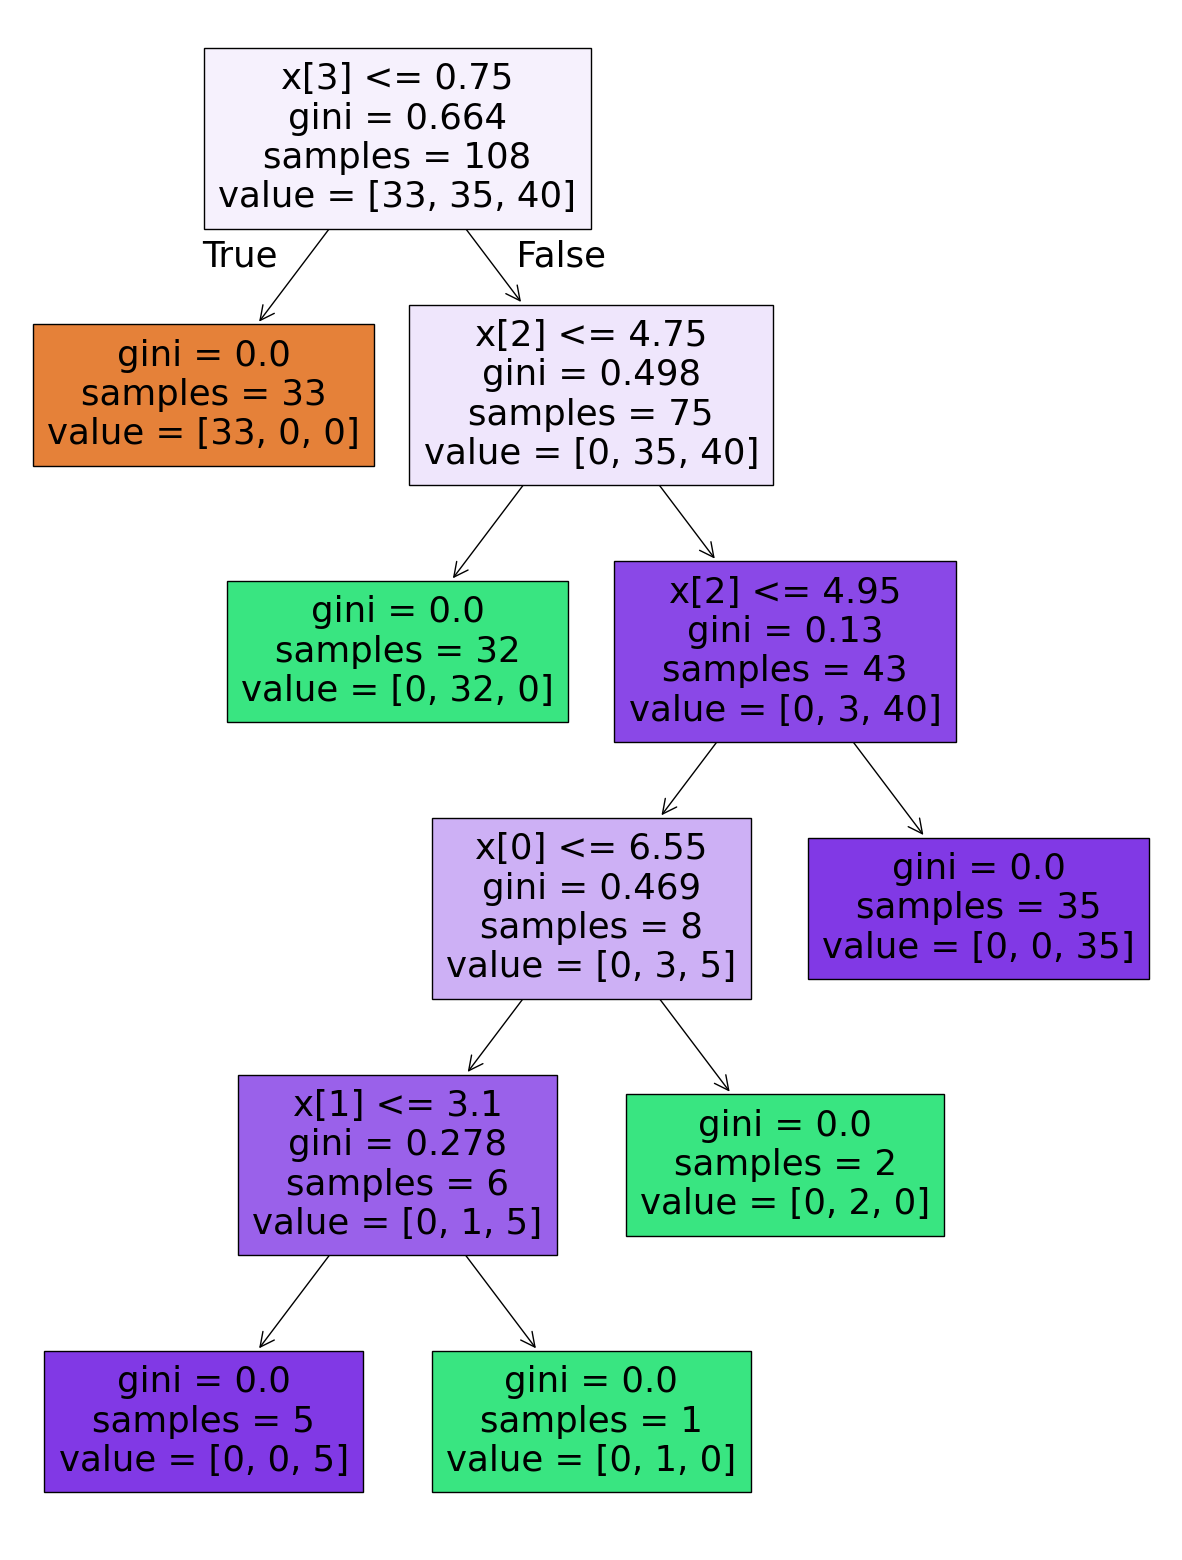

In [179]:
# 4 code: 
clf4 = DecisionTreeClassifier(random_state=0,criterion='gini')
clf4.fit(x_train_2, y_train_2)
print(clf2.score(x_test_2, y_test_2))

plt.figure(figsize=(15,20))
t = tree.plot_tree(clf4,filled=True)
# enter code here

# Part C - Classify handwritten digits with random forest

As discussed in lecture and readings, usually we will not make just one decision tree, but rather use an emsemble of them called a random forest. Random forests have many applications and can even be used for image recognition. In this part, we will examine how we could use random forest to classifiy handwritten digits using another classic machine learning dataset. 

This dataset is called MNIST and is used to test many machine learning models (for more information, see http://yann.lecun.com/exdb/mnist/). We'll use our usual framework for an ML workflow for this part.

## C1 Big Picture  

Optical character recognition (OCR) is a very common machine learning task that is used to digitize handwriting. There is a lot of variation in how people write, but the number of possible characters is fairly small, so it is a well defined task. For this part of the lab, we'll try to identify numbers, which means there will be 10 classes (zero to nine). 

## C2 Get the data

In [181]:
from sklearn.datasets import load_digits
digits = load_digits()
digits.keys() # the data is in the form of a dictionary, this will let you see the keys

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

## C3 Explore the data


## Question 12
(2 pts)

Check the shape, and head, plot, visualize, and have a look at the data with whatever ways you think will help your task. Comment throughout on observations. There is some code below to look at some sample of digits

# statistics comment:
there are too many pixels so it is not easy to analyse these data...

In [185]:
from sklearn.utils import Bunch
bdigits = Bunch(data=digits.data, target=digits.target, feature_names=digits.feature_names)
pdigits = pd.DataFrame(data=bdigits.data, columns=bdigits.feature_names)
print(pdigits.describe())

       pixel_0_0    pixel_0_1    pixel_0_2    pixel_0_3    pixel_0_4  \
count     1797.0  1797.000000  1797.000000  1797.000000  1797.000000   
mean         0.0     0.303840     5.204786    11.835838    11.848080   
std          0.0     0.907192     4.754826     4.248842     4.287388   
min          0.0     0.000000     0.000000     0.000000     0.000000   
25%          0.0     0.000000     1.000000    10.000000    10.000000   
50%          0.0     0.000000     4.000000    13.000000    13.000000   
75%          0.0     0.000000     9.000000    15.000000    15.000000   
max          0.0     8.000000    16.000000    16.000000    16.000000   

         pixel_0_5    pixel_0_6    pixel_0_7    pixel_1_0    pixel_1_1  ...  \
count  1797.000000  1797.000000  1797.000000  1797.000000  1797.000000  ...   
mean      5.781859     1.362270     0.129661     0.005565     1.993879  ...   
std       5.666418     3.325775     1.037383     0.094222     3.196160  ...   
min       0.000000     0.000000    

# head count comment:
some of the digits in the middle fire while the edge ones don't.

In [189]:
print(pdigits.head())

   pixel_0_0  pixel_0_1  pixel_0_2  pixel_0_3  pixel_0_4  pixel_0_5  \
0        0.0        0.0        5.0       13.0        9.0        1.0   
1        0.0        0.0        0.0       12.0       13.0        5.0   
2        0.0        0.0        0.0        4.0       15.0       12.0   
3        0.0        0.0        7.0       15.0       13.0        1.0   
4        0.0        0.0        0.0        1.0       11.0        0.0   

   pixel_0_6  pixel_0_7  pixel_1_0  pixel_1_1  ...  pixel_6_6  pixel_6_7  \
0        0.0        0.0        0.0        0.0  ...        0.0        0.0   
1        0.0        0.0        0.0        0.0  ...        0.0        0.0   
2        0.0        0.0        0.0        0.0  ...        5.0        0.0   
3        0.0        0.0        0.0        8.0  ...        9.0        0.0   
4        0.0        0.0        0.0        0.0  ...        0.0        0.0   

   pixel_7_0  pixel_7_1  pixel_7_2  pixel_7_3  pixel_7_4  pixel_7_5  \
0        0.0        0.0        6.0       13.0

# PCA plot comments: 
reduce all the pixels to two uncorrelated clusters and see how digits are clustered: 2, 8, 5 are pretty spread, which might indicate difficulty in correctly predicting these digits.  other digits seem to be well separated.
    

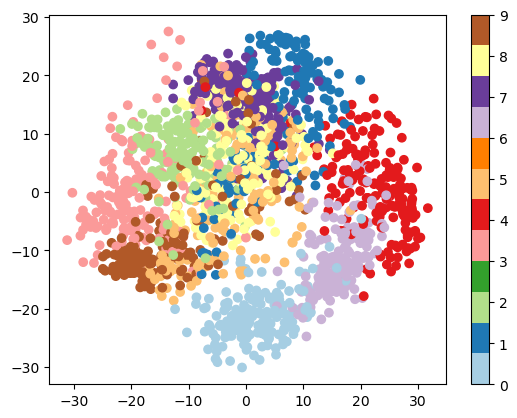

In [198]:
# This code is from AI
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
proj = pca.fit_transform(digits.data)
plt.scatter(proj[:, 0], proj[:, 1], c=digits.target, cmap='Paired')
plt.colorbar()
plt.show()

# Code given in the notebook

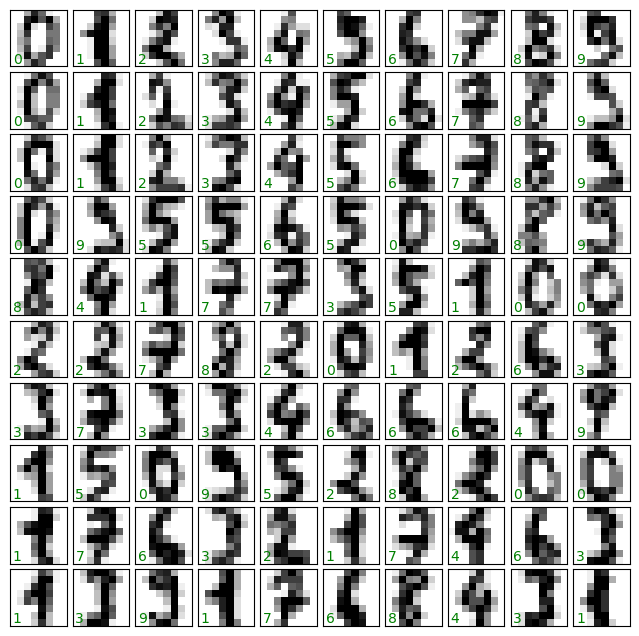

In [17]:
# We can display some of the digits to see what they look like
fig, axes = plt.subplots(10, 10, figsize=(8, 8),
                         subplot_kw={'xticks':[], 'yticks':[]},
                         gridspec_kw=dict(hspace=0.1, wspace=0.1))

for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='binary', interpolation='nearest')
    ax.text(0.05, 0.05, str(digits.target[i]),
            transform=ax.transAxes, color='green')

## C4 Prepare Data

For this assignment, the data is already prepared and is part of the digits dictionary. No need to do anything else for this part.

## C5 Select model and train


## Question 12
(6 pts)

Here, we'll be using the pixels as features and the digit as the target. We will use the random forest classifier from sklearn to model the data. 

Remember, in this part, you'll need to :

- Split the data into training, validation, and testing
- Build a random forest classifier 
- Train the classifier 


In [201]:
# your code here 
from sklearn.ensemble import RandomForestClassifier

data=np.array(digits.data)
targets=np.array(digits.target)
np.random.seed(10)
# Run this code to randomly shuffle the data and make train and validation splits
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data, targets, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)



### Performance / evaluation metrics

## Question 13
(6 pts)

We have mainly been using **accuracy score** as a metric for classification, but that is just one measure of how well our predictions are. For this part, let's compute some additional metrics.

- First, compute the accuracy score of your random forest classifier. 
- Compute the confusion matrix and plot it (see lab 1)
- Learn about and compute another classification metric in sklearn: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics

# Accuracy score
98.77%

In [202]:
rfc=RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)


print(rfc.score(x_test, y_test))

0.9876543209876543


# Confusion matrix

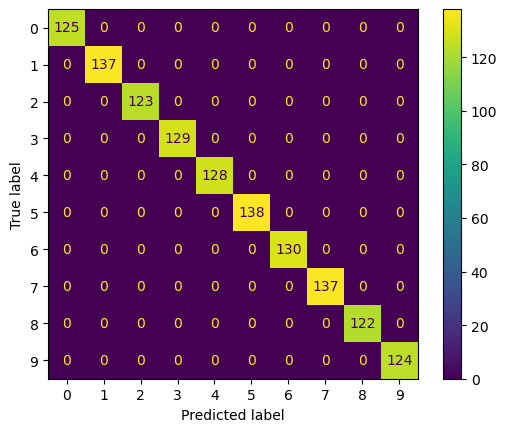

In [20]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, roc_curve

cm = confusion_matrix(y_train,rfc.predict(x_train))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc.classes_)
disp.plot()
plt.show()

#can also use a heat map

## 3.6 Fine tune model


## Question 14
(6 pts)

The random forest classifier has many hyper-parameters to tune that can make your classification better. Here, you'll conduct some systematic experiments in tuning hyper-parameters to see how they affect the model performance. 

- First, read the documentation for the random forest classifier to see the different hyper-parameters https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- Pick one of the hyper-parameters to tune (some examples are: ``n_estimators``, ``max_depth``, ``min_samples_leaf``, ``max_leaf_nodes``)
- Systematically vary one of these hyper-parameters and record your performance metric (for example accuracy score). Plot this relationship. 
- If you want to search multiple parameters in a grid, sklearn also has a wrapper function that is very useful called ``GridSearchCV`` https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
- Discuss the results of your experiments

## 3.7 Present solution

## Question 15
(4 pts)

Using the testing data that you left out in the beginning, compute your final performance metrics. Also plot the final confusion matrix. Discuss where your model is good and where the model can still be improved. 

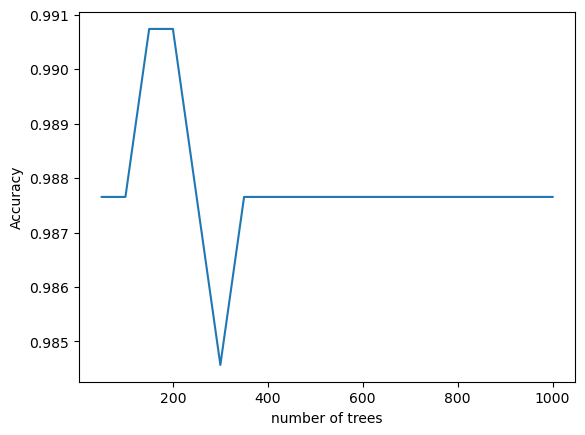

In [204]:
# your code here
n_d=20
es_p = np.zeros([n_d, 2])
for i in np.arange(1,n_d+1):
    rfc_int=RandomForestClassifier(random_state=42, n_estimators=i*100)
    rfc_int.fit(x_train, y_train)
    es_p[i-1,0] = i*100
    es_p[i-1,1] = rfc_int.score(x_test, y_test)

plt.plot(es_p[:,0],es_p[:,1])
plt.xlabel("number of trees")
plt.ylabel("Accuracy")

plt.show()

# comment:
The accuracy increases linearly with the number of trees in the forest until 50 but decreases since then for a while but then decreases briefly.  I think with a larger range, the trend might be overall increasing.

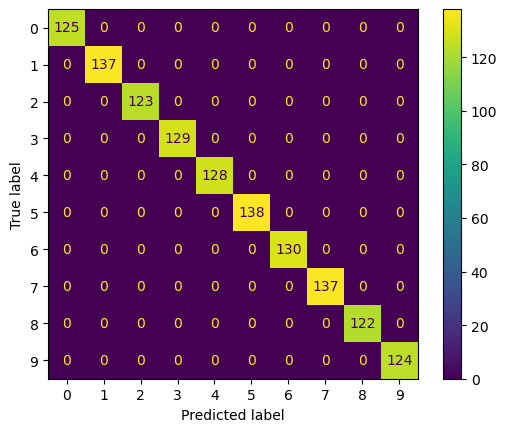

In [208]:
rfc_new=RandomForestClassifier(random_state=42, n_estimators=1000)
rfc_new.fit(x_train, y_train)

cm = confusion_matrix(y_train,rfc_new.predict(x_train))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc_new.classes_)
disp.plot()
plt.show()

# Comment:
> Discuss where your model is good and where the model can still be improved.

There is no false predictions (off-diagonal entries of confusion matrix) and so our model looks pretty good.

## 3.8. Launch, Monitor and Maintain

Nothing to here for this lab. 

# Part D - Machine Learning in Particle Physics


## D1 - The Big Picture 

In this part, you will build a random forest machine learning model to recongnize types creating of top-quarks in a particle accelarator based on the observed products. We can use the decay products, energy, and momentum vectors to infer the presense of top-quarks. Beyond Standard Model Particle physics models often predict new types of particles so knowing whether the number of top-quarks (which have very high energy compared to other quarks) are as expected can be important for identifying when the Standard Model breaks down. 

Before you begin this experiment, read more about the dataset in Chapter 4, Section 4.1 of the Machine Learning for Physics and Astronomy in the PDF in the lab directory (also on Bruinlearn). 



## D2 - Get the Data

The dataset is included here in `ParticleID_features.csv`, the target is in `'ParticleID_labels.txt`. Our goal is to differentiate between the `4-top` events (Interactions of 4 top quark) from the `ttbar` events (interaction of top and anti-top quarks background events). 

In [85]:
## get the data

import pandas as pd
features = pd.read_csv('ParticleID_features.csv')
targets = pd.read_csv('ParticleID_labels.txt',header=None)

## D3 - Explore the data

In this lab, you have the freedom to decide what features you would like to use to train your model and how to clean and inpute your data. 

To help guide you, be sure to answer the following questions about the data. Read Chapter 4, Section 4.1 and 4.3 of the included PDF to learn more and get ideas of how to deal with cleaning the data and selecting good features to use. This chapter also has helpful pandas and sklearn code that will help make some of these tasks easier. Use the ``features.describe()`` to see the statistics of the columns of the ``features`` table. 

## Question 16
(4 pts)

1. What are the columns and what do they mean?
2. Why do some columns have more NaN's than others? 
3. Examine your target classes. What is the distribution of the number of training samples for the two classes? 
4. Make plots to explore some of the features that you are interested in using. 



# 1

Each sample corresponds to one event.  In an single event, there are up to 12 particles generated. For each particle, we have MET, METphi, Type and four Ps.  MET and METphi are missing energy magnitude and angle.  Type is the particle species.  P_{4n+1}, ..., P_{4n+4} are the 4-momenta of the nth particle.  

# 2

Some events produce less than 12 particles.

In [31]:
features

,ID,MET,METphi,Type_1,P1,P2,P3,P4,Type_2,P5,...,Type_12,P45,P46,P47,P48,Type_13,P49,P50,P51,P52
0,0,62803.5,-1.810010,j,137571.0,128444.0,-0.345744,-0.307112,j,174209.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,57594.2,-0.509253,j,161529.0,80458.3,-1.318010,1.402050,j,291490.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,82313.3,1.686840,b,167130.0,113078.0,0.937258,-2.068680,j,102423.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,30610.8,2.617120,j,112267.0,61383.9,-1.211050,-1.457800,b,40647.8,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,45153.1,-2.241350,j,178174.0,100164.0,1.166880,-0.018721,j,92351.3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,4995,269074.0,-1.274730,j,495577.0,362590.0,-0.791914,1.671250,b,328278.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4996,4996,12385.8,0.986871,j,258932.0,133559.0,-1.276540,2.970100,j,87822.2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4997,4997,32762.8,3.057630,b,122222.0,79947.8,0.983920,-0.399231,j,260623.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4998,4998,104474.0,-1.875250,b,791028.0,457589.0,1.141530,2.934810,b,304661.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
features.describe()

,ID,MET,METphi,P1,P2,P3,P4,P5,P6,P7,...,P43,P44,P45,P46,P47,P48,P49,P50,P51,P52
count,5000.000000,5000.000000,5000.000000,5.000000e+03,5.000000e+03,5000.000000,5000.000000,4.997000e+03,4.997000e+03,4997.000000,...,261.000000,261.000000,1.270000e+02,127.000000,127.000000,127.000000,5.600000e+01,56.000000,56.000000,56.000000
mean,2499.500000,64071.074332,-0.028916,3.301357e+05,1.540486e+05,-0.039812,-0.003049,2.527799e+05,1.080302e+05,-0.029936,...,0.029455,0.026422,1.631051e+05,34876.849606,0.206978,-0.001085,1.456600e+05,36151.183929,-0.000879,0.219260
std,1443.520003,60525.122480,1.819257,3.068202e+05,1.149469e+05,1.361762,1.814855,2.638580e+05,8.136261e+04,1.439105,...,1.884750,1.753017,2.248603e+05,20433.767238,1.998859,1.949004,1.943657e+05,25861.883410,1.941707,1.910400
min,0.000000,290.756000,-3.141010,3.857940e+04,2.825400e+04,-4.110220,-3.140710,1.087540e+04,1.080000e+04,-4.668790,...,-4.400470,-3.130690,1.780380e+04,12987.900000,-4.447660,-3.139820,2.512510e+04,14836.000000,-4.448760,-2.990730
25%,1249.750000,24352.375000,-1.619905,1.369522e+05,8.883690e+04,-1.035570,-1.574213,1.007510e+05,6.321840e+04,-1.060500,...,-1.413650,-1.270700,4.365005e+04,24742.500000,-1.259230,-1.817600,4.112588e+04,24974.125000,-1.243362,-1.490900
50%,2499.500000,46814.400000,-0.055612,2.263525e+05,1.182015e+05,-0.038731,-0.009037,1.659740e+05,8.584360e+04,-0.057428,...,-0.088908,-0.041002,8.050910e+04,28262.800000,0.120301,-0.232455,9.553645e+04,27353.550000,-0.121213,0.128103
75%,3749.250000,83032.350000,1.537323,4.077158e+05,1.771265e+05,0.943598,1.542370,2.999950e+05,1.238700e+05,1.028340,...,1.416310,1.514030,1.578350e+05,35445.700000,1.727295,1.712720,1.754910e+05,33817.950000,1.800682,1.984745
max,4999.000000,692674.000000,3.141130,3.186360e+06,1.276710e+06,4.141410,3.138540,3.587700e+06,1.146330e+06,4.559150,...,4.790720,3.120760,1.246080e+06,167840.000000,4.691500,3.091510,1.177730e+06,155888.000000,4.151320,3.058890


In [86]:
targets

,0
0,ttbar
1,ttbar
2,ttbar
3,ttbar
4,ttbar
...,...
4995,4top
4996,ttbar
4997,ttbar
4998,4top


# 3

What is the distribution of the number of training samples for the two classes?

There are 4189 ttbars and 811 4tops.

In [52]:
targets[0].value_counts()

0
ttbar    4189
4top      811
Name: count, dtype: int64

## D4 - Prepare the Data

Here, you'll be selecting the features and creating your training, testing, and validating data. Again, Chapter 4, Section 4.1 and 4.3 will be helpful for this. 

## Question 17
(6 pts)

1. Choose at least 5 features to use in your random forest model and justfy why you think these are helpful features.
2. Do you need to clean these features? Are there invalid or missing values that you need to deal with? If so describe your method for dealing with them. 
3. Split your dataset into training, testing, and validation. You are free to choose what fraction you would like to use for each. 


# 1 
Q: Choose at least 5 features to use in your random forest model and justfy why you think these are helpful features.

A: Based on the pairplot, missing energy and direction and each energy (P1, P5, ...) don't seem to have a distinguishing power, while the first momentum component (P2, P6, ...) does.  We choose P2 and P6 and also added total energy and total number of particles generated.

In [166]:
new_features = features.loc[:,["P2","P6"]]
# new_features['Type_2'] = features['Type_2'].astype('category').cat.codes
new_features['N_ptl'] = 12-features.loc[:,["Type_1","Type_2","Type_3","Type_4","Type_5","Type_6","Type_7","Type_8","Type_9","Type_10","Type_11","Type_12"]].isna().sum(axis=1)
new_features['E_tot'] = features.loc[:,[features.columns[4+5*x] for x in range(0,12)]].sum(axis=1)
new_features['p_tot'] = features.loc[:,[features.columns[5+5*x] for x in range(0,12)]].sum(axis=1)
# new_features['E_Miss/E_tot'] = features.loc[:,"MET"]/new_features['E_tot']
new_features['target'] = targets[0]
new_features.head()

,P2,P6,N_ptl,E_tot,p_tot,target
0,128444.0,127932.0,5,624088.5,487989.1,ttbar
1,80458.3,68462.9,4,570173.0,210963.0,ttbar
2,113078.0,54922.3,5,434875.9,256515.4,ttbar
3,61383.9,39472.0,5,472835.9,186686.9,ttbar
4,100164.0,69762.1,5,1182928.5,277383.1,ttbar


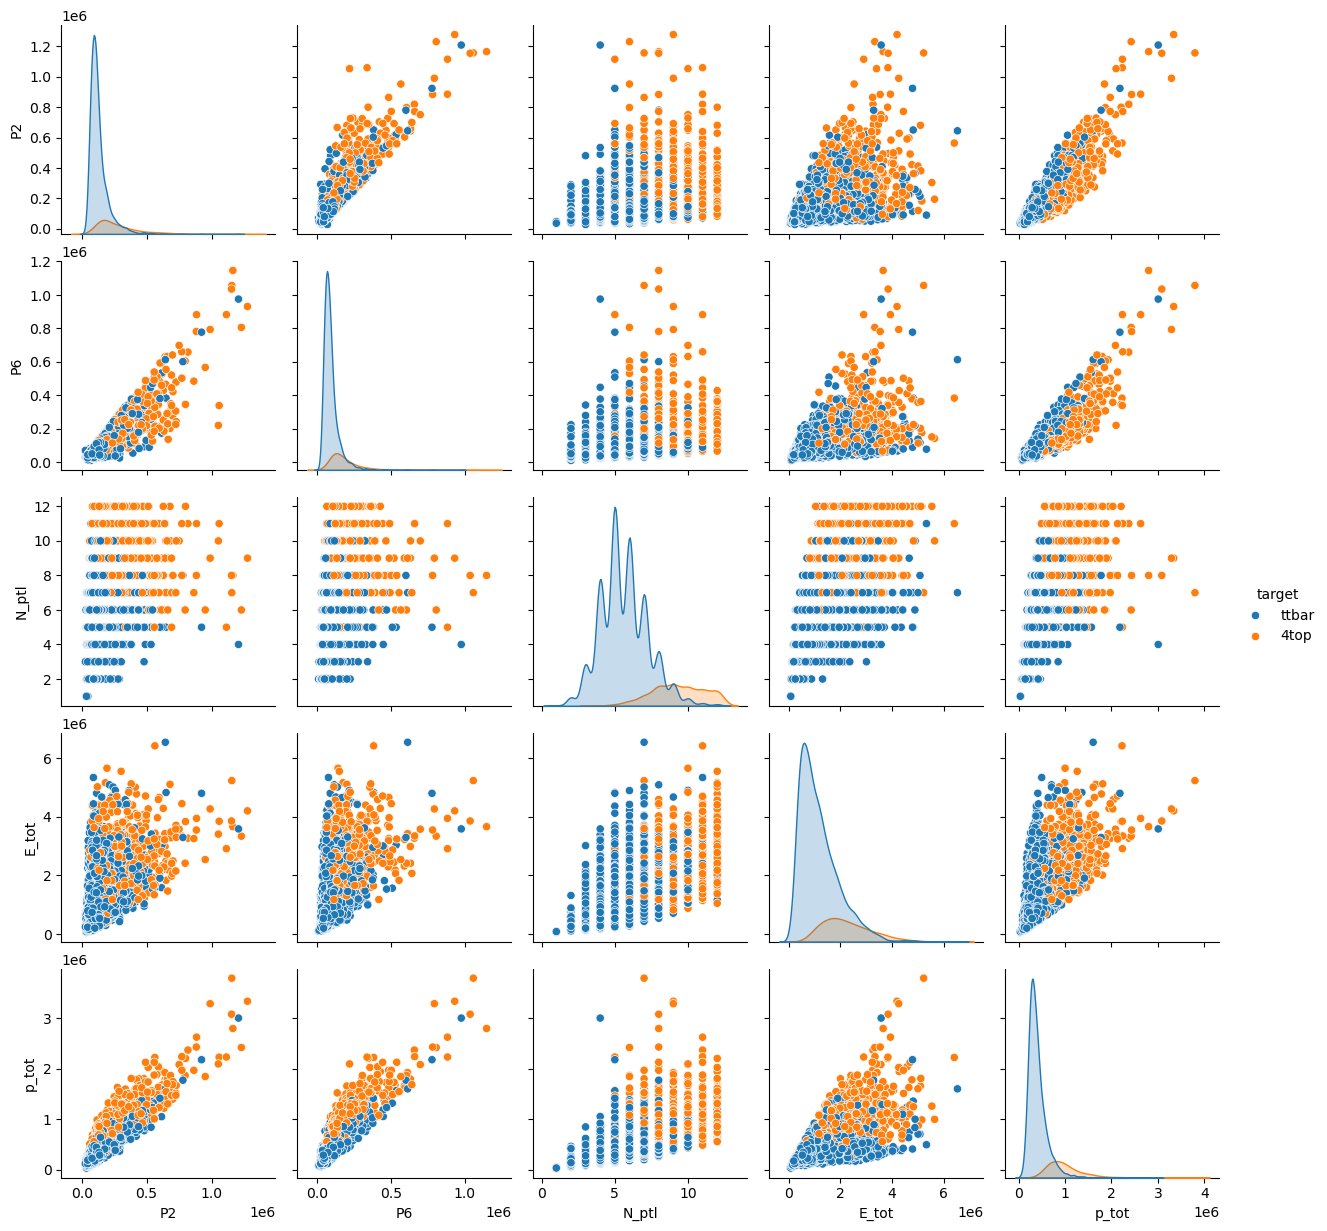

In [167]:
sns.pairplot(new_features, hue='target')

# 3
Q: Do you need to clean these features? Are there invalid or missing values that you need to deal with? If so describe your method for dealing with them.

A: There are some outliers, with 'larger' values.  Since the histograms below show the most data are cramped within 2.5 sigmas, we truncate using that threshold.  The skitlearn decision tree has a way to deal with the missing data so I will leave it as is.  

395999.9435187396 196832.6605979051


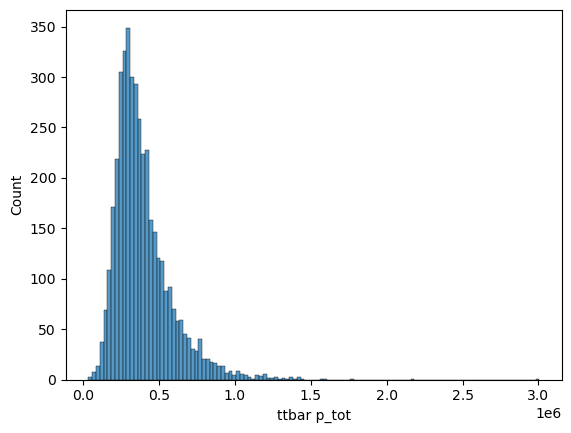

In [88]:
hist = sns.histplot(data = new_features.loc[new_features.target == 'ttbar'].p_tot)
hist.set(xlabel = "ttbar p_tot")
print(new_features.loc[new_features.target == 'ttbar'].p_tot.mean(), new_features.loc[new_features.target == 'ttbar'].p_tot.std())

In [89]:
p_mean, p_std = new_features.loc[new_features.target == 'ttbar'].p_tot.mean(), new_features.loc[new_features.target == 'ttbar'].p_tot.std()
p_mean2, p_std2 = new_features.loc[new_features.target == '4top'].p_tot.mean(), new_features.loc[new_features.target == '4top'].p_tot.std()
threshold = 2
cleaned_features = new_features.loc[((new_features.target == '4top') & ((new_features['p_tot'] - p_mean2) <= threshold * p_std2)) | ((new_features.target == 'ttbar') & ((new_features['p_tot'] - p_mean) <= threshold * p_std)) ]
print(new_features.P2.count(), cleaned_features.P2.count())
print(f'ratio of retained data {cleaned_features.P2.count()/new_features.P2.count() * 100}')

5000 4786
ratio of retained data 95.72


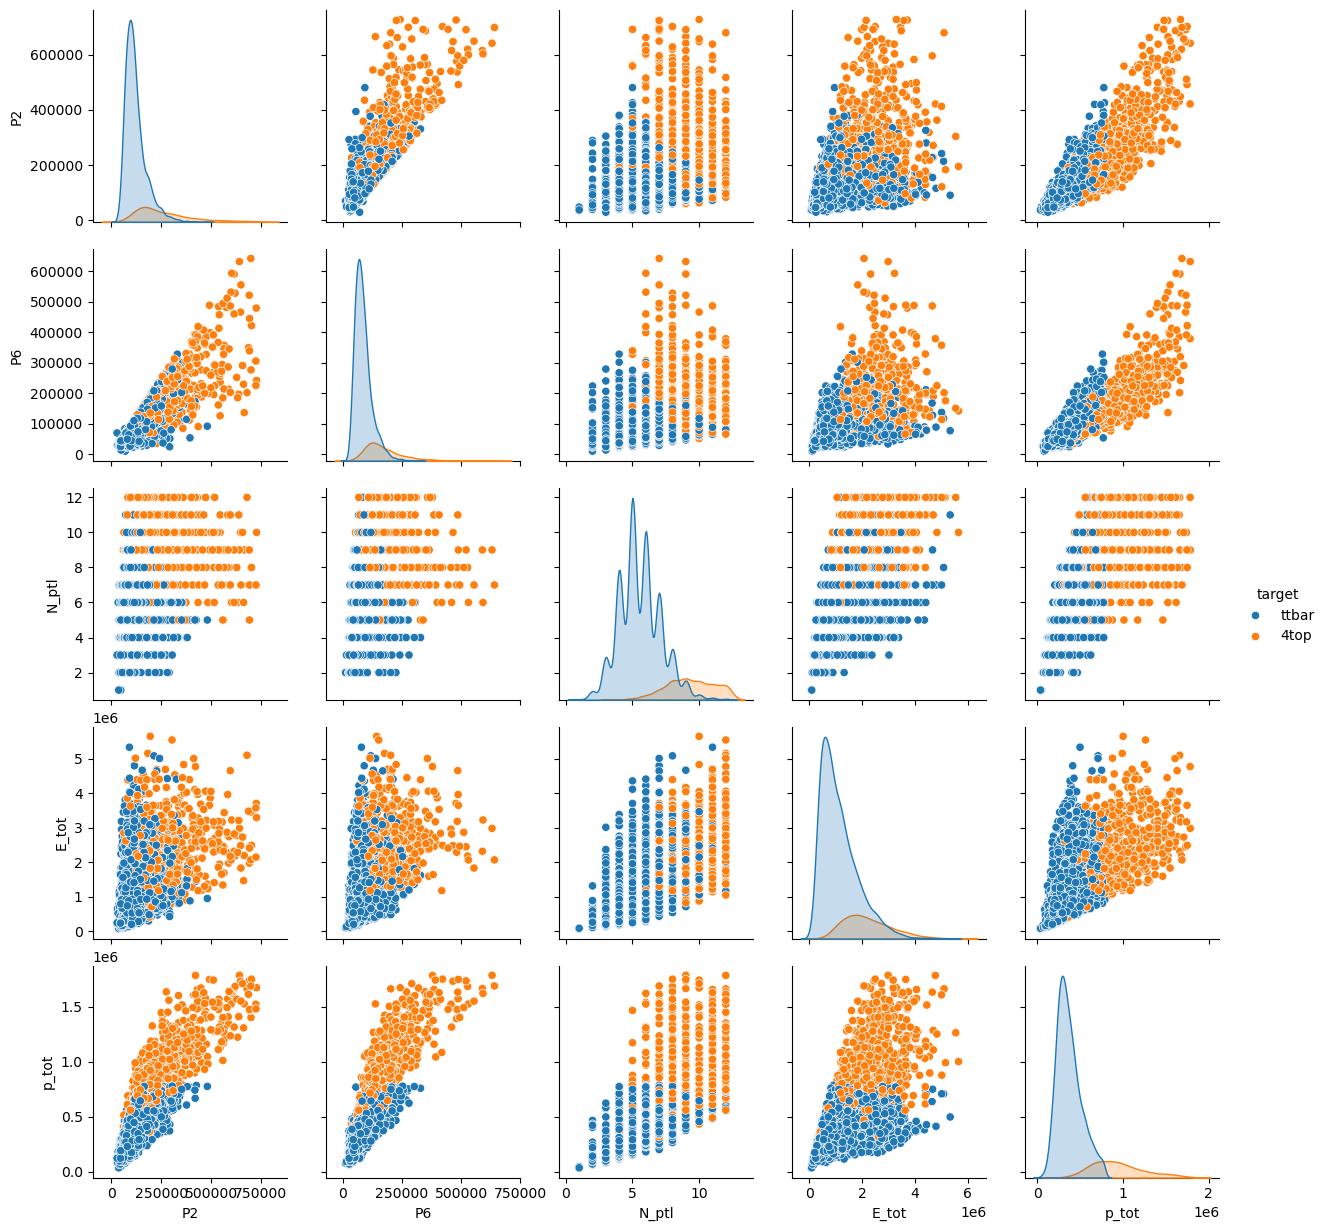

In [60]:
sns.pairplot(cleaned_features, hue='target')

In [78]:
from sklearn.ensemble import RandomForestClassifier

data=np.array(new_features.iloc[:,:-1])
targets=np.array(targets)
np.random.seed(42)
# Run this code to randomly shuffle the data and make train and validation splits
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data, targets, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc=RandomForestClassifier(n_estimators=100, random_state=42)
rfc.fit(x_train, y_train)
selected_score = rfc.score(x_test, y_test)
selected_score2 = rfc.score(x_validate, y_validate)
print(rfc.score(x_test, y_test))

/opt/conda/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9133333333333333


In [82]:
from sklearn.ensemble import RandomForestClassifier

data0 =np.array(features.select_dtypes(include=np.number))
targets=np.array(targets)
np.random.seed(42)
# Run this code to randomly shuffle the data and make train and validation splits
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data0, targets, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc_crude=RandomForestClassifier(n_estimators=100, random_state=42)
rfc_crude.fit(x_train, y_train)
raw_score = rfc_crude.score(x_test, y_test)
raw_score2 = rfc_crude.score(x_validate, y_validate)
print(rfc_crude.score(x_test, y_test))

/opt/conda/lib/python3.12/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.9222222222222223


In [79]:
data2=np.array(cleaned_features.iloc[:,:-1])
targets2=np.array(cleaned_features.iloc[:,-1])
np.random.seed(42)
# now split the training data further into training and testing
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data2, targets2, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc_cl=RandomForestClassifier(n_estimators=100, random_state=42)
rfc_cl.fit(x_train, y_train)
cl_score = rfc_cl.score(x_test, y_test)
cl_score2 = rfc_cl.score(x_validate, y_validate)
print(f'test score: {rfc_cl.score(x_test, y_test)},\t validation score: {rfc_cl.score(x_validate, y_validate)}')

test score: 0.9605568445475638,	 validation score: 0.9582463465553236


In [83]:
print(f'test scores\n all features: {np.round(raw_score,2)}, \t selected features: {np.round(selected_score,2)}, \t cleaned selected: {np.round(cl_score,2)}')
print(f'validation scores\n all features: {np.round(raw_score2,2)}, \t selected features: {np.round(selected_score2,2)}, \t cleaned selected: {np.round(cl_score2,2)}')

test scores
 all features: 0.92, 	 selected features: 0.91, 	 cleaned selected: 0.96
validation scores
 all features: 0.94, 	 selected features: 0.94, 	 cleaned selected: 0.96


## D5 - Select model and train

## Question 18
(3 pts)

Use a random forest classifier to train a model to classify `4-top` and ``ttbar`` events. 

In [131]:
data2=np.array(cleaned_features.iloc[:,:-1])
targets2=np.array(cleaned_features.iloc[:,-1])
np.random.seed(42)
# now split the training data further into training and testing
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data2, targets2, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc_cl=RandomForestClassifier(n_estimators=100, random_state=42)
rfc_cl.fit(x_train, y_train)
cl_score = rfc_cl.score(x_test, y_test)
cl_score2 = rfc_cl.score(x_validate, y_validate)

print(f'test score: {rfc_cl.score(x_test, y_test)},\t validation score: {rfc_cl.score(x_validate, y_validate)}')

test score: 0.9605568445475638,	 validation score: 0.9582463465553236


## Performance and evaluation metrics


## Question 19
(6 pts)

- First, compute the accuracy score of your random forest classifier. Based on the ratio of ``4-top`` samples compared to the ``ttbar`` class, what accuracy would you expect if you always guess ``ttbar``?
- Use ``sklearn.metrics.classification_report`` to compute some other common metrics. Descibe what each metric means. 
- Compute the confusion matrix and plot it.

# Q1
if you always guess ttbar, it is correct by 84.57%

In [102]:
np.count_nonzero(y_test == 'ttbar')/(np.count_nonzero(y_test == '4top') + np.count_nonzero(y_test == 'ttbar'))

0.845707656612529

# Q2

In [108]:
print(sk.metrics.classification_report(y_test, rfc_cl.predict(x_test)))

              precision    recall  f1-score   support

        4top       0.91      0.83      0.87       133
       ttbar       0.97      0.98      0.98       729

    accuracy                           0.96       862
   macro avg       0.94      0.91      0.92       862
weighted avg       0.96      0.96      0.96       862



Let TP = true positive, FP = false positive, TN = true negative, FN = false negative.

precision = TP/(TP+FP)
recall (sensitivity) = TP/(TP+FN)
f1-score = harmonic mean of precision and recall

# Q3

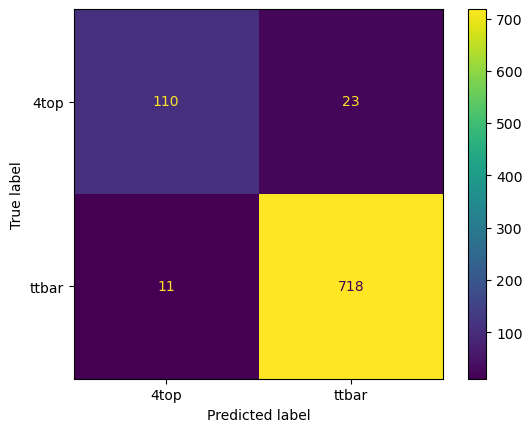

In [115]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, roc_curve

cm = confusion_matrix(y_test,rfc_cl.predict(x_test))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rfc_cl.classes_)
disp.plot()
plt.show()

In the following code, we display the "normalised" confusion matrix, the code is from GeeksforGeeks.

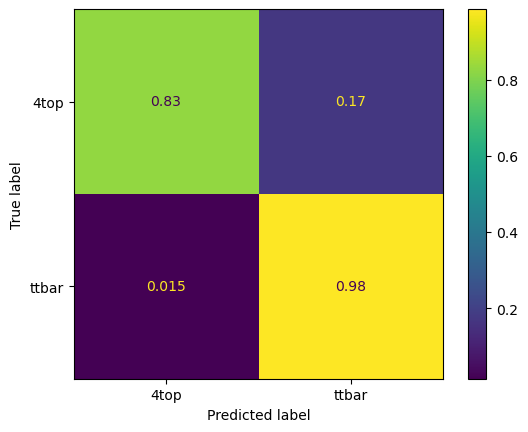

In [128]:
def normalize_confusion_matrix(cm, norm='true'):
    """
    Normalize a confusion matrix.
    
    Parameters:
    cm (array-like): Confusion matrix to be normalized.
    norm (str): Type of normalization ('true', 'pred', 'all').
    
    Returns:
    ndarray: Normalized confusion matrix.
    """
    if norm == 'true':
        cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    elif norm == 'pred':
        cm_normalized = cm.astype('float') / cm.sum(axis=0)[np.newaxis, :]
    elif norm == 'all':
        cm_normalized = cm.astype('float') / cm.sum()
    else:
        raise ValueError("Unknown normalization type. Use 'true', 'pred', or 'all'.")
    
    return cm_normalized

cm = confusion_matrix(y_test,rfc_cl.predict(x_test))
cm_normalized = normalize_confusion_matrix(cm, norm='true')


disp = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=rfc_cl.classes_)
disp.plot()
plt.show()

## D6 - Fine tune your model

## Question 20
(6 pts)

Re-run your random forest classifier with other choices for hyper-parameters. Are there better choies of hyper-parameters? Describe your final model and justify your choices. 

# Answer
The hyperparameters and their default values of random forest classifier are n_estimators=100, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1,min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, ...

In [152]:
data2=np.array(cleaned_features.iloc[:,:-1])
targets2=np.array(cleaned_features.iloc[:,-1])
np.random.seed(42)
# now split the training data further into training and testing
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data2, targets2, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc_cl2=RandomForestClassifier(n_estimators=1000, criterion = 'gini', random_state=42)
rfc_cl2.fit(x_train, y_train)

print(f'before fine tuning:\n {sk.metrics.classification_report(y_test, rfc_cl.predict(x_test))}')
print(f'after:\n {sk.metrics.classification_report(y_test, rfc_cl2.predict(x_test))}')

before fine tuning:
               precision    recall  f1-score   support

        4top       0.91      0.83      0.87       133
       ttbar       0.97      0.98      0.98       729

    accuracy                           0.96       862
   macro avg       0.94      0.91      0.92       862
weighted avg       0.96      0.96      0.96       862

after:
               precision    recall  f1-score   support

        4top       0.92      0.83      0.87       133
       ttbar       0.97      0.99      0.98       729

    accuracy                           0.96       862
   macro avg       0.95      0.91      0.93       862
weighted avg       0.96      0.96      0.96       862



In [170]:
data2=np.array(cleaned_features.iloc[:,:-1])
targets2=np.array(cleaned_features.iloc[:,-1])
np.random.seed(42)
# now split the training data further into training and testing
x_train_all, x_validate, y_train_all, y_validate = model_selection.train_test_split(data2, targets2, test_size=0.1)

# now split the training data further into training and testing
x_train, x_test, y_train, y_test = model_selection.train_test_split(x_train_all, y_train_all, test_size=0.2)

rfc_cl2=RandomForestClassifier(n_estimators=100, max_depth=20, criterion = 'gini', random_state=42,  min_samples_leaf=2)
rfc_cl2.fit(x_train, y_train)

print(f'before fine tuning:\n {sk.metrics.classification_report(y_test, rfc_cl.predict(x_test))}')
print(f'after:\n {sk.metrics.classification_report(y_test, rfc_cl2.predict(x_test))}')

before fine tuning:
               precision    recall  f1-score   support

        4top       0.91      0.83      0.87       133
       ttbar       0.97      0.98      0.98       729

    accuracy                           0.96       862
   macro avg       0.94      0.91      0.92       862
weighted avg       0.96      0.96      0.96       862

after:
               precision    recall  f1-score   support

        4top       0.94      0.82      0.88       133
       ttbar       0.97      0.99      0.98       729

    accuracy                           0.96       862
   macro avg       0.95      0.90      0.93       862
weighted avg       0.96      0.96      0.96       862



# A
After adjusting hyperparameters such as n_estimator, max_depth, min_samples_leaf, criterion, etc., nothing really improved the performance and changing some of them worsen the performance.

## D7 - Present your solution


## Question 21
(6 pts)

Describe the performance of your model on the validation data set. Describe two improvements that one could make in this work in the future (for example how to improve: data collection, feature engineering, data cleaning, model buiding, etc.). 

In [168]:
print(sk.metrics.classification_report(y_validate, rfc_cl2.predict(x_validate)))

              precision    recall  f1-score   support

        4top       0.90      0.82      0.86        78
       ttbar       0.97      0.98      0.97       401

    accuracy                           0.96       479
   macro avg       0.93      0.90      0.92       479
weighted avg       0.96      0.96      0.96       479



# A
If I know the physics behind ttbar and 4-top production, I would be better at selecting the right features.  But I think it is also possible that the decision tree or random forest is not good for this type of classification.

# Submit your lab

You're done! Congrats!